<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/Improve_Plant_Disease_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install & Import Libraries**

In [ ]:
# Install kagglehub if not already installed
!pip install kagglehub -q

In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub

In [ ]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [ ]:
# Download PlantVillage dataset
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
print("Dataset Path:", path)

TRAIN_PATH = os.path.join(path, "PlantVillage", "train")
VAL_PATH   = os.path.join(path, "PlantVillage", "val")

classes = os.listdir(TRAIN_PATH)
num_classes = len(classes)
print(f"Total Classes: {num_classes}")

Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset Path: /kaggle/input/plantvillage
Total Classes: 38


# **Data Augmentation & Loading**

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training transforms — more aggressive augmentation for real-world robustness
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),            # Random crop instead of fixed resize
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),                # Increased rotation range
    transforms.ColorJitter(brightness=0.3,        # Handle lighting variation
                           contrast=0.3,
                           saturation=0.3,
                           hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])   # ImageNet mean/std (required for VGG16)
])

# Validation transforms — no augmentation, just resize
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=VAL_PATH,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Training Images  : {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")

Training Images  : 43444
Validation Images: 10861


# **VGG16 Transfer Learning Model**

In [ ]:
def build_vgg16_model(num_classes, freeze_features=True):
    # Load VGG16 with pretrained ImageNet weights
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    # Step 1: Freeze all convolutional layers (feature extractor)
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    # Step 2: Replace the classifier (fully connected layers)
    # VGG16's original classifier outputs 1000 classes (ImageNet)
    # We replace it with our own for 38 classes
    model.classifier = nn.Sequential(
        nn.Linear(25088, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(1024, num_classes)   # 38 output classes
    )

    return model

model = build_vgg16_model(num_classes=num_classes, freeze_features=True)
model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 135MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Count trainable vs frozen parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params   = total_params - trainable_params

print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters   : {frozen_params:,}")

Total Parameters    : 121,713,510
Trainable Parameters: 106,998,822
Frozen Parameters   : 14,714,688


# **Loss Function, Optimizer & Scheduler**

In [ ]:
criterion = nn.CrossEntropyLoss()

# Only pass trainable parameters to the optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

# Learning rate scheduler — reduces LR when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print("Loss function, Optimizer, and Scheduler ready!")

Loss function, Optimizer, and Scheduler ready!


# **Training Loop**

In [ ]:
EPOCHS = 10

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_acc = 0.0   # Track best model

for epoch in range(EPOCHS):
    start_time = time.time()

    # ── Training Phase ──────────────────────────────────────
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # ── Validation Phase ─────────────────────────────────────
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # ── Metrics ───────────────────────────────────────────────
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_val_loss   = val_loss   / len(val_loader.dataset)
    epoch_train_acc  = 100 * correct_train / total_train
    epoch_val_acc    = 100 * correct_val   / total_val

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)

    # Step the scheduler based on validation loss
    scheduler.step(epoch_val_loss)

    # Save best model checkpoint
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_plant_disease_vgg16.pth')
        print(f" Best model saved! Val Acc: {epoch_val_acc:.2f}%")

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% | "
          f"Time: {elapsed:.1f}s")

print(f"\nTraining Complete! Best Validation Accuracy: {best_val_acc:.2f}%")

 Best model saved! Val Acc: 68.80%
Epoch [01/10] | Train Loss: 1.2777, Acc: 63.88% | Val Loss: 0.9676, Acc: 68.80% | Time: 495.8s
 Best model saved! Val Acc: 72.00%
Epoch [02/10] | Train Loss: 0.9781, Acc: 72.42% | Val Loss: 0.8793, Acc: 72.00% | Time: 430.2s
 Best model saved! Val Acc: 77.95%
Epoch [03/10] | Train Loss: 0.9160, Acc: 74.81% | Val Loss: 0.7141, Acc: 77.95% | Time: 431.4s
 Best model saved! Val Acc: 80.25%
Epoch [04/10] | Train Loss: 0.8916, Acc: 75.79% | Val Loss: 0.6937, Acc: 80.25% | Time: 434.3s
Epoch [05/10] | Train Loss: 0.8739, Acc: 76.53% | Val Loss: 0.6838, Acc: 78.93% | Time: 425.5s
 Best model saved! Val Acc: 81.59%
Epoch [06/10] | Train Loss: 0.8304, Acc: 77.77% | Val Loss: 0.6162, Acc: 81.59% | Time: 434.7s
 Best model saved! Val Acc: 83.08%
Epoch [07/10] | Train Loss: 0.8381, Acc: 77.70% | Val Loss: 0.5582, Acc: 83.08% | Time: 430.1s
Epoch [08/10] | Train Loss: 0.8210, Acc: 78.34% | Val Loss: 0.5959, Acc: 82.52% | Time: 420.3s
 Best model saved! Val Acc: 83

# **Plot Training History**

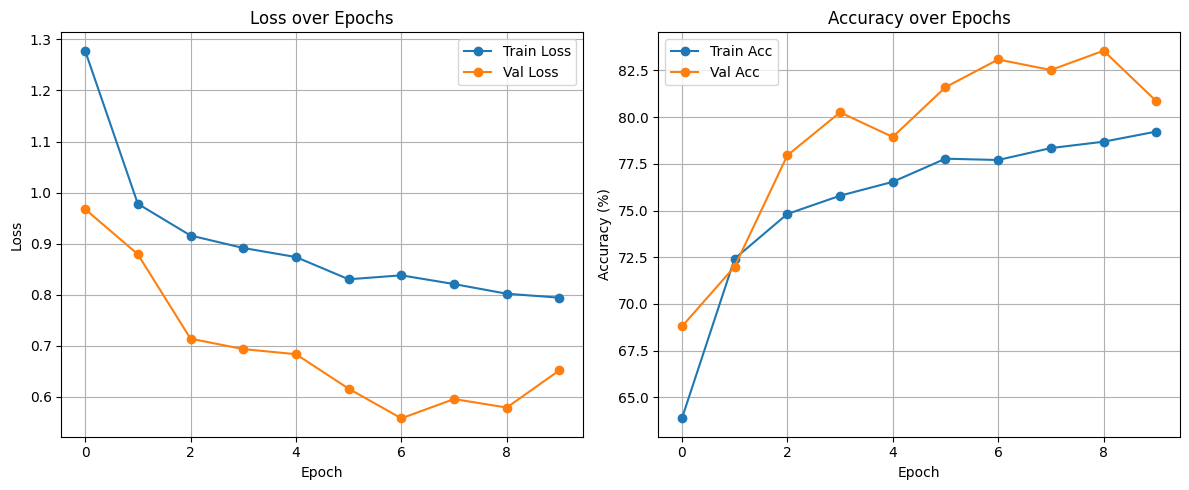

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', marker='o')
plt.plot(history['val_loss'],   label='Val Loss',   marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', marker='o')
plt.plot(history['val_acc'],   label='Val Acc',   marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **Inference (Single Image Prediction)**

In [ ]:
def predict_image(image_path, model, transform, class_names, device):
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)        # Convert to probabilities
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = class_names[predicted.item()]
    confidence_pct  = confidence.item() * 100

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence_pct:.2f}%")
    plt.axis('off')
    plt.show()

    print(f"Predicted Class : {predicted_class}")
    print(f"Confidence      : {confidence_pct:.2f}%")

    # Show top 3 predictions
    top3_probs, top3_indices = torch.topk(probabilities, 3, dim=1)
    print("\nTop 3 Predictions:")
    for i in range(3):
        cls  = class_names[top3_indices[0][i].item()]
        prob = top3_probs[0][i].item() * 100
        print(f"  {i+1}. {cls}: {prob:.2f}%")

Best model loaded!


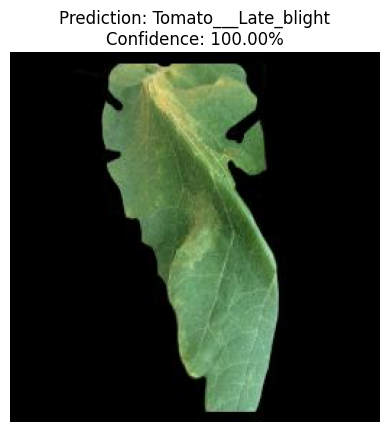

Predicted Class : Tomato___Late_blight
Confidence      : 100.00%

Top 3 Predictions:
  1. Tomato___Late_blight: 100.00%
  2. Tomato___Bacterial_spot: 0.00%
  3. Tomato___Tomato_Yellow_Leaf_Curl_Virus: 0.00%


In [ ]:
# Load best saved model before predicting
model.load_state_dict(torch.load('best_plant_disease_vgg16.pth', map_location=device))
print("Best model loaded!")

# Test with a validation image
test_image_path = os.path.join(VAL_PATH, classes[0],
                               os.listdir(os.path.join(VAL_PATH, classes[0]))[0])
predict_image(test_image_path, model, val_transform, train_dataset.classes, device)

# **Test with Unseen Images**

Upload your real-world test images:


Saving tomato_spider.jpg to tomato_spider.jpg

Image: tomato_spider.jpg


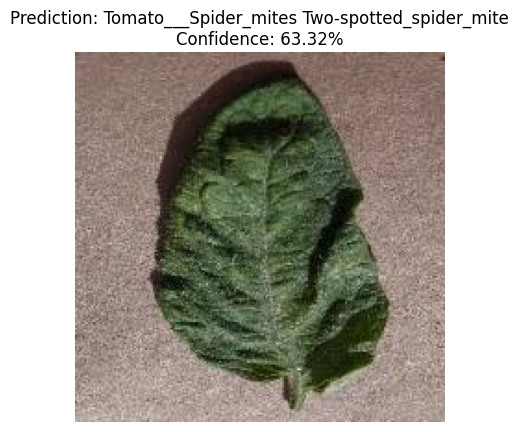

Predicted Class : Tomato___Spider_mites Two-spotted_spider_mite
Confidence      : 63.32%

Top 3 Predictions:
  1. Tomato___Spider_mites Two-spotted_spider_mite: 63.32%
  2. Tomato___Tomato_Yellow_Leaf_Curl_Virus: 34.24%
  3. Tomato___Leaf_Mold: 1.24%


In [ ]:
# Upload your external images in Colab first, then predict
from google.colab import files

print("Upload your real-world test images:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n{'='*40}")
    print(f"Image: {filename}")
    predict_image(filename, model, val_transform, train_dataset.classes, device)

# **Fine-Tuning**

In [ ]:
# ── Phase 2: Fine-Tuning ──────────────────────────────────────────
# Load the best model saved during Phase 1
model.load_state_dict(torch.load('best_plant_disease_vgg16.pth', map_location=device))
print("Best Phase 1 model loaded!")

# VGG16 features has 31 layers (index 0–30)
# We unfreeze the last 2 conv blocks (from layer 17 onwards)
for i, layer in enumerate(model.features):
    if i >= 17:
        for param in layer.parameters():
            param.requires_grad = True
    # layers 0–16 stay frozen

# Verify which layers are now trainable
print("\nLayer freeze status:")
for i, layer in enumerate(model.features):
    trainable = any(p.requires_grad for p in layer.parameters())
    status = " Trainable" if trainable else "  Frozen"
    print(f"  Layer {i:02d} ({layer.__class__.__name__}): {status}")

Best Phase 1 model loaded!

Layer freeze status:
  Layer 00 (Conv2d):   Frozen
  Layer 01 (ReLU):   Frozen
  Layer 02 (Conv2d):   Frozen
  Layer 03 (ReLU):   Frozen
  Layer 04 (MaxPool2d):   Frozen
  Layer 05 (Conv2d):   Frozen
  Layer 06 (ReLU):   Frozen
  Layer 07 (Conv2d):   Frozen
  Layer 08 (ReLU):   Frozen
  Layer 09 (MaxPool2d):   Frozen
  Layer 10 (Conv2d):   Frozen
  Layer 11 (ReLU):   Frozen
  Layer 12 (Conv2d):   Frozen
  Layer 13 (ReLU):   Frozen
  Layer 14 (Conv2d):   Frozen
  Layer 15 (ReLU):   Frozen
  Layer 16 (MaxPool2d):   Frozen
  Layer 17 (Conv2d):  Trainable
  Layer 18 (ReLU):   Frozen
  Layer 19 (Conv2d):  Trainable
  Layer 20 (ReLU):   Frozen
  Layer 21 (Conv2d):  Trainable
  Layer 22 (ReLU):   Frozen
  Layer 23 (MaxPool2d):   Frozen
  Layer 24 (Conv2d):  Trainable
  Layer 25 (ReLU):   Frozen
  Layer 26 (Conv2d):  Trainable
  Layer 27 (ReLU):   Frozen
  Layer 28 (Conv2d):  Trainable
  Layer 29 (ReLU):   Frozen
  Layer 30 (MaxPool2d):   Frozen


In [ ]:
# Use a much smaller learning rate for fine-tuning
# Large LR would destroy the pretrained weights
optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001        # 10x smaller than Phase 1
)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='min',
    patience=2,
    factor=0.5
)

print("Fine-tuning optimizer ready! LR = 0.0001")

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Now training {trainable_params:,} / {total_params:,} parameters")

Fine-tuning optimizer ready! LR = 0.0001
Now training 119,978,022 / 121,713,510 parameters


In [ ]:
# Fine-Tuning Training Loop
EPOCHS_FT = 10

history_ft = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_acc_ft = 84.60   # Start from Phase 1's best — only save if we beat this

for epoch in range(EPOCHS_FT):
    start_time = time.time()

    # ── Training ────────────────────────────────────────────
    model.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_ft.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_ft.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # ── Validation ──────────────────────────────────────────
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    # ── Metrics ─────────────────────────────────────────────
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_val_loss   = val_loss   / len(val_loader.dataset)
    epoch_train_acc  = 100 * correct_train / total_train
    epoch_val_acc    = 100 * correct_val   / total_val

    history_ft['train_loss'].append(epoch_train_loss)
    history_ft['val_loss'].append(epoch_val_loss)
    history_ft['train_acc'].append(epoch_train_acc)
    history_ft['val_acc'].append(epoch_val_acc)

    scheduler_ft.step(epoch_val_loss)

    # Save only if better than Phase 1 best
    if epoch_val_acc > best_val_acc_ft:
        best_val_acc_ft = epoch_val_acc
        torch.save(model.state_dict(), 'best_plant_disease_finetuned.pth')
        print(f"New best model saved! Val Acc: {epoch_val_acc:.2f}%")

    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1:02d}/{EPOCHS_FT}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.2f}% | "
          f"Time: {elapsed:.1f}s")

print(f"\nFine-Tuning Complete! Best Validation Accuracy: {best_val_acc_ft:.2f}%")

In [ ]:
# Plot Fine-Tuning History

plt.figure(figsize=(12, 5))



plt.subplot(1, 2, 1)

plt.plot(history_ft['train_loss'], label='Train Loss', marker='o', color='blue')

plt.plot(history_ft['val_loss'],   label='Val Loss',   marker='o', color='orange')

plt.title('Fine-Tuning: Loss over Epochs')

plt.xlabel('Epoch'); plt.ylabel('Loss')

plt.legend(); plt.grid(True)



plt.subplot(1, 2, 2)

plt.plot(history_ft['train_acc'], label='Train Acc', marker='o', color='blue')

plt.plot(history_ft['val_acc'],   label='Val Acc',   marker='o', color='orange')

plt.axhline(y=84.60, color='red', linestyle='--', label='Phase 1 Best (84.60%)')

plt.title('Fine-Tuning: Accuracy over Epochs')

plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')

plt.legend(); plt.grid(True)



plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Save the best fine-tuned model
torch.save(model.state_dict(), 'plant_disease_finetuned.pth')
print("Fine-tuned model saved!")

from google.colab import files
files.download('plant_disease_finetuned.pth')